# CellChatPy analysis of multiple spatial transcriptomics datasets

This notebook demonstrates CellChatPy on two adult human intestine 10X Visium replicates, A1 and A2.

CellChatPy uses normalized expression, spot annotations, sample labels, full-resolution spatial coordinates, spatial scale factors, and the human ligand-receptor database to infer communication across the combined datasets. Spatial distances are calculated within each replicate, so coordinates from different tissue sections are never treated as neighboring spots.

The tutorial covers:

1. Load and validate two canonical CellChatPy spatial H5 inputs.
2. Select secreted signaling interactions from the human CellChatDB.
3. Infer ligand-receptor communication probabilities and pathway-level networks.
4. Extract significant communication tables and inspect EGF signaling.
5. Visualize aggregate networks, pathway networks, centrality, contribution, and spatial gene expression.
6. Optionally export communication tables and the complete CellChat object.

## Setup and imports

The setup cell locates the repository from either the project root or `tutorial/`, imports the local `CellChatPy` package, and defines one helper that saves, displays, and closes every Matplotlib figure exactly once.

In [1]:
from pathlib import Path
import pickle
import platform
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore", message="divide by zero encountered in log")

project_root = next(
    (path for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
     if (path / "CellChatPy").is_dir() and (path / "data").is_dir()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Cannot locate a repository containing CellChatPy/ and data/.")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import CellChatPy as cc

%matplotlib inline

sample_paths = {
    "A1": project_root / "data" / "human_intestine_A1.h5",
    "A2": project_root / "data" / "human_intestine_A2.h5",
}
figure_dir = (
    project_root / "tutorial" / "figures_multiple_spatial_transcriptomics"
).resolve()
result_dir = (project_root / "tutorial" / "multiple_spatial_tutorial_output").resolve()
figure_dir.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name):
    """Validate, save, display, and close one Matplotlib figure."""
    if fig is None:
        print(f"  [SKIP] {name} returned None")
        return None

    path = figure_dir / name
    try:
        fig.savefig(path, dpi=150, bbox_inches="tight")
    except OSError as exc:
        raise OSError(
            f"Could not save figure to {str(path)!r}: {type(exc).__name__}: {exc}"
        ) from exc

    print(f"  Saved: {path}")
    plt.show()
    plt.close(fig)
    return None

print("Python:", platform.python_version())
print("CellChatPy:", cc.__version__)
print("Repository:", project_root)
print("Inputs:")
for sample, path in sample_paths.items():
    print(f"  {sample}: {path}")

c:\anaconda\envs\pytorch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: 3.11.13
CellChatPy: 1.1.0
Repository: E:\Jin\cellchat.python_new
Inputs:
  A1: E:\Jin\cellchat.python_new\data\human_intestine_A1.h5
  A2: E:\Jin\cellchat.python_new\data\human_intestine_A2.h5


---

## Part I: Load and validate spatial replicates

Each canonical spatial H5 file contains a spots-by-genes expression matrix, spot metadata, full-resolution coordinates, and `ratio`/`tol` spatial factors. The two replicates are validated independently before merging. `merge_spatial_inputs` retains genes shared by both samples, prefixes spot identifiers with the sample name, and records the ordered sample labels in `cellchat_dataset`.

In [2]:
ptm = time.time()
sample_names = tuple(sample_paths)
spatial_inputs = []

for sample, path in sample_paths.items():
    if not path.is_file():
        raise FileNotFoundError(f"Spatial input for {sample} was not found: {path}")

    item = cc.read_spatial_h5(path, sample=sample)
    expression = item["expression"]
    item_genes = [str(gene) for gene in item["genes"]]
    item_spots = [str(spot) for spot in item["cells"]]
    item_metadata = item["metadata"]
    item_coordinates = item["coordinates"]

    if expression.shape != (len(item_spots), len(item_genes)):
        raise ValueError(f"{sample}: expression must have spots as rows and genes as columns.")
    expression_values = expression.data if hasattr(expression, "data") else np.asarray(expression)
    if not np.isfinite(expression_values).all():
        raise ValueError(f"{sample}: expression contains NaN or infinite values.")
    if len(set(item_spots)) != len(item_spots) or len(set(item_genes)) != len(item_genes):
        raise ValueError(f"{sample}: spot names and gene names must each be unique.")
    if item_metadata.index.astype(str).tolist() != item_spots:
        raise ValueError(f"{sample}: metadata is not aligned with expression rows.")
    if item_coordinates.index.astype(str).tolist() != item_spots:
        raise ValueError(f"{sample}: coordinates are not aligned with expression rows.")
    required_columns = {"cellchat_group", "cellchat_dataset"}
    missing_columns = required_columns.difference(item_metadata.columns)
    if missing_columns:
        raise ValueError(f"{sample}: metadata is missing {sorted(missing_columns)}.")
    if item_metadata[list(required_columns)].isna().any().any():
        raise ValueError(f"{sample}: group and dataset labels cannot be missing.")
    if not np.isfinite(item_coordinates.to_numpy(dtype=float)).all():
        raise ValueError(f"{sample}: coordinates must contain only finite numbers.")
    for factor_name in ("ratio", "tol"):
        factor = np.asarray(item["spatial_factors"][factor_name], dtype=float).reshape(-1)
        if factor.size != 1 or not np.isfinite(factor).all() or np.any(factor <= 0):
            raise ValueError(
                f"{sample}: spatial_factors[{factor_name!r}] must contain one positive value."
            )

    spatial_inputs.append(item)
    print(f"{sample}: {expression.shape[0]:,} spots x {expression.shape[1]:,} genes")

inputs = cc.merge_spatial_inputs(spatial_inputs, sample_names=sample_names)

data_input = inputs["expression"]
genes = [str(gene) for gene in inputs["genes"]]
spots = [str(spot) for spot in inputs["cells"]]
metadata = inputs["metadata"].copy()
coordinates = inputs["coordinates"].copy()
spatial_factors = inputs["spatial_factors"]

if data_input.shape != (len(spots), len(genes)):
    raise ValueError("Merged expression must have spots as rows and genes as columns.")
if metadata.index.astype(str).tolist() != spots:
    raise ValueError("Merged metadata is not aligned with expression rows.")
if coordinates.index.astype(str).tolist() != spots:
    raise ValueError("Merged coordinates are not aligned with expression rows.")
if metadata["cellchat_dataset"].cat.categories.tolist() != list(sample_names):
    raise ValueError("Merged sample categories do not preserve the requested sample order.")
for factor_name in ("ratio", "tol"):
    factor = np.asarray(spatial_factors[factor_name], dtype=float).reshape(-1)
    if factor.size != len(sample_names) or not np.isfinite(factor).all() or np.any(factor <= 0):
        raise ValueError(
            f"spatial_factors[{factor_name!r}] must contain one positive value per sample."
        )

print("Expression matrix (spots x genes):", data_input.shape)
print("Common genes:", len(genes))
print("Samples:")
display(metadata["cellchat_dataset"].value_counts(sort=False).to_frame("spots"))
print("Cell groups:")
display(metadata["cellchat_group"].value_counts(sort=False).to_frame("spots"))
display(
    pd.DataFrame(spatial_factors, index=sample_names)
    .rename_axis("sample")
    .rename(columns={"ratio": "micrometers_per_pixel", "tol": "spot_radius_um"})
)

A1: 2,649 spots x 15,882 genes
A2: 2,316 spots x 16,514 genes
Expression matrix (spots x genes): (4965, 15609)
Common genes: 15609
Samples:


,spots
cellchat_dataset,
A1,2649
A2,2316


Cell groups:


,spots
cellchat_group,
Myofibroblasts,316
Cycling Cells,591
Undifferentiated,761
Glial,147
DC2,37
B-Cells,150
Goblets,331
T-Cells,25
Plasma Cells,387


,micrometers_per_pixel,spot_radius_um
sample,,
A1,0.7399,32.5
A2,0.7446,32.5


In [3]:
cellchat = cc.create_cellchat(
    data_input,
    metadata=metadata,
    group_by="cellchat_group",
    datatype="spatial",
    coordinates=coordinates,
    spatial_factors=spatial_factors,
    genes=genes,
    cells=spots,
)

if cellchat.obs_names.astype(str).tolist() != spots:
    raise AssertionError("CellChat spot names changed during object creation.")
if cellchat.var_names.astype(str).tolist() != genes:
    raise AssertionError("CellChat gene names changed during object creation.")

print(cellchat)
print("Cell groups:", list(cellchat.groups.categories))

Create a CellChat object from a data matrix
Cell groups used for CellChat analysis: ['Myofibroblasts', 'Cycling Cells', 'Undifferentiated', 'Glial', 'DC2', 'B-Cells', 'Goblets', 'T-Cells', 'Plasma Cells', 'Colonocytes', 'Crypt Top Colonocytes', 'ILCs', 'Mast Cells', 'BEST4+/OTOP2+ Cell', 'NK', 'Endothelial 2', 'Enteroendocrines', 'Stromal 3', 'Stromal 1', 'Stromal 2', 'Pericytes', 'Endothelial 1', 'DC1', 'Macrophages&Monocytes', 'Stromal 4']
Create a CellChat object from spatial transcriptomics data...
An object of class CellChat created from a single dataset
15609 genes, 4965 cells
CellChat analysis of SPATIAL data!
The input spatial locations are:
                            0       1
A1_AAACAAGTATCTCCCA-1  4372.0  5303.0
A1_AAACAGAGCGACTCCT-1  1753.0  4960.0
A1_AAACATTTCCCGGATT-1  5173.0  5097.0
A1_AAACCACTACACAGAT-1   949.0  5919.0
A1_AAACCCGAACGAAATC-1  4006.0  5846.0
Cell groups: ['Myofibroblasts', 'Cycling Cells', 'Undifferentiated', 'Glial', 'DC2', 'B-Cells', 'Goblets', 'T-Cell

c:\anaconda\envs\pytorch\Lib\site-packages\anndata\_core\anndata.py:402: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


  Saved: E:\Jin\cellchat.python_new\tutorial\figures_multiple_spatial_transcriptomics\00_spatial_annotations.png


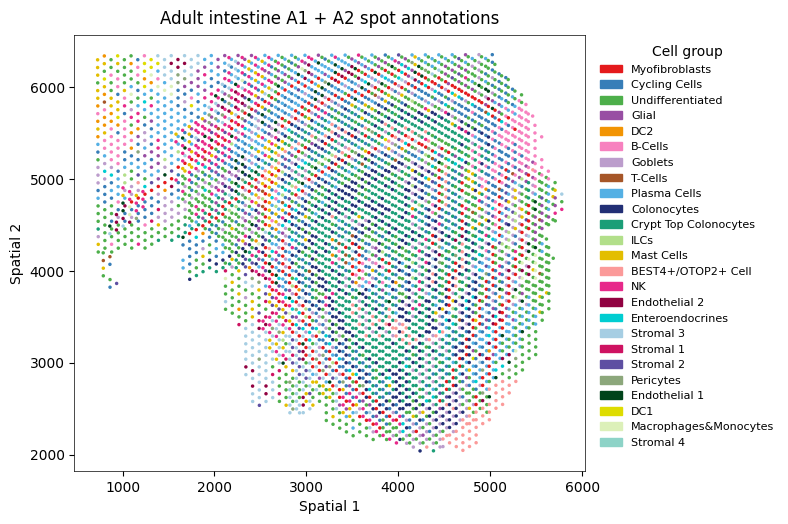

In [18]:
color_use = cc.sc_palette(metadata["cellchat_group"].nunique())
fig = cc.plot_spatial_dim(
    cellchat,
    color_use=color_use,
    title_name="Adult intestine A1 + A2 spot annotations",
    pt_size=2.5,
    pt_alpha=1.0,
    fig_size=(8, 7),
    return_fig=True,
)
save_fig(fig, "00_spatial_annotations.png")

### Select the ligand-receptor interaction database

This analysis uses the secreted signaling subset of the human CellChatDB. The category plot summarizes the interaction classes in the complete database before subsetting.

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_multiple_spatial_transcriptomics\00_database_category.png


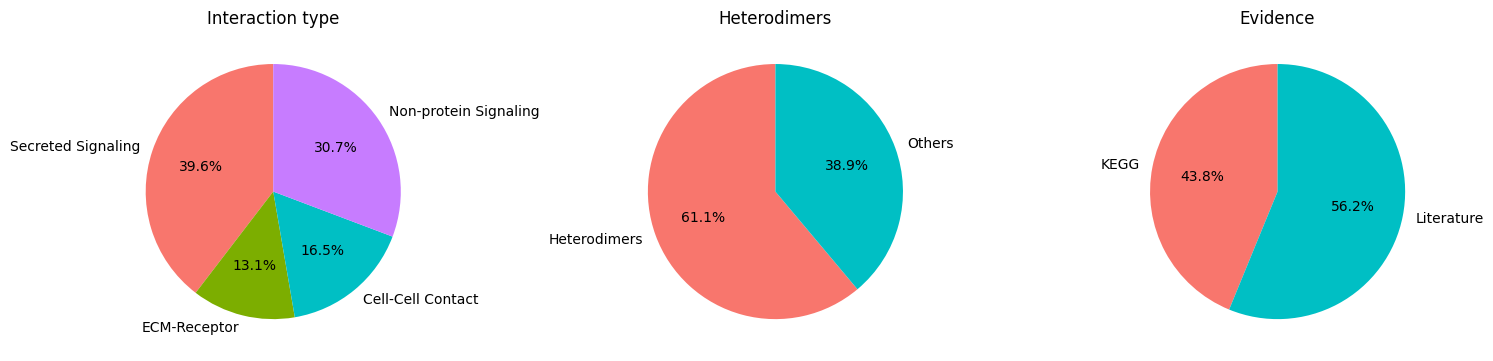

Secreted-signaling interactions: 1280


In [5]:
db_human = cc.load_database("human")
fig = cc.show_database_category(db_human)
save_fig(fig, "00_database_category.png")

db_use = cc.subset_database(
    db_human, search="Secreted Signaling", key="annotation"
)
cellchat = cc.set_database(cellchat, database=db_use)
print("Secreted-signaling interactions:", len(db_use["interaction"]))

### Identify candidate signaling interactions

The standard CellChat workflow first restricts the expression matrix to database signaling features, then identifies over-expressed genes and candidate ligand-receptor interactions.

In [6]:
cellchat = cc.subset_signaling_data(cellchat)
cellchat = cc.identify_overexpressed_genes(cellchat)
cellchat = cc.identify_overexpressed_interactions(cellchat)

lr_sig = cellchat.lr_pairs["significant"]
print("Signaling expression (spots x genes):", cellchat.signaling.shape)
print(f"Candidate over-expressed L-R pairs: {len(lr_sig):,}")
display(lr_sig[["interaction_name", "pathway_name", "ligand", "receptor"]].head(10))

The number of highly variable ligand-receptor pairs used for signaling inference is 422
Signaling expression (spots x genes): (4965, 15609)
Candidate over-expressed L-R pairs: 422


,interaction_name,pathway_name,ligand,receptor
TGFB1_TGFBR1_TGFBR2,TGFB1_TGFBR1_TGFBR2,TGFb,TGFB1,TGFbR1_R2
TGFB3_TGFBR1_TGFBR2,TGFB3_TGFBR1_TGFBR2,TGFb,TGFB3,TGFbR1_R2
TGFB1_ACVR1B_TGFBR2,TGFB1_ACVR1B_TGFBR2,TGFb,TGFB1,ACVR1B_TGFbR2
TGFB1_ACVR1C_TGFBR2,TGFB1_ACVR1C_TGFBR2,TGFb,TGFB1,ACVR1C_TGFbR2
TGFB3_ACVR1B_TGFBR2,TGFB3_ACVR1B_TGFBR2,TGFb,TGFB3,ACVR1B_TGFbR2
TGFB3_ACVR1C_TGFBR2,TGFB3_ACVR1C_TGFBR2,TGFb,TGFB3,ACVR1C_TGFbR2
TGFB1_ACVR1_TGFBR1,TGFB1_ACVR1_TGFBR1,TGFb,TGFB1,ACVR1_TGFbR
TGFB3_ACVR1_TGFBR1,TGFB3_ACVR1_TGFBR1,TGFb,TGFB3,ACVR1_TGFbR
BMP2_BMPR1A_ACVR2A,BMP2_BMPR1A_ACVR2A,BMP,BMP2,BMPR1A_ACVR2A
BMP2_BMPR1A_ACVR2B,BMP2_BMPR1A_ACVR2B,BMP,BMP2,BMPR1A_ACVR2B


---

## Part II: Infer spatial communication

This example follows the R multiple-spatial-dataset vignette with a 10% truncated mean, a 250 micrometer diffusion range, spatial distance weighting, and a 100 micrometer contact range for 10X Visium data. A scale factor of `0.013` keeps the minimum scaled group distance at least 1 for these H5 inputs while remaining close to the R vignette's `0.01`. CellChatPy uses `cellchat_dataset` to calculate spot and group distances within A1 and A2 separately, then aggregates evidence across the replicates.

The tutorial uses `n_boot=20` for a practical demonstration. Increase the number of permutations for a final biological analysis when runtime permits.

In [7]:
n_boot = 20

inference_started = time.time()
cellchat = cc.compute_communication_probability(
    cellchat,
    type_method="truncatedMean",
    trim=0.1,
    distance_use=True,
    interaction_range=250,
    scale_distance=0.013,
    contact_dependent=True,
    contact_range=100,
    n_boot=n_boot,
    seed_use=1,
)
cellchat = cc.filter_communication(cellchat, min_cells=10)
df_net = cc.subset_communication(
    cellchat, slot_name="network", thresh_pval=0.05
)

print(f"Significant cell-group/L-R communications: {len(df_net):,}")
display(df_net.head(10))

truncatedMean is used for calculating the average gene expression per cell group.
Pre-computing 20 bootstrap averaged expressions...
Computing communication probabilities for 422 LR pairs...
>>> CellChat inference is done.
Results stored in .network.
Excluding cell groups due to few cells: ['Stromal 4']
Significant cell-group/L-R communications: 2,445


,source,target,ligand,receptor,prob,pval,interaction_name,interaction_name_2,pathway_name,annotation,evidence
0,Myofibroblasts,Myofibroblasts,TGFB1,TGFbR1_R2,0.000029,0.0,TGFB1_TGFBR1_TGFBR2,TGFB1 - (TGFBR1+TGFBR2),TGFb,Secreted Signaling,KEGG: hsa04350
1,Myofibroblasts,Cycling Cells,TGFB1,TGFbR1_R2,0.000012,0.0,TGFB1_TGFBR1_TGFBR2,TGFB1 - (TGFBR1+TGFBR2),TGFb,Secreted Signaling,KEGG: hsa04350
2,Myofibroblasts,Enteroendocrines,TGFB1,TGFbR1_R2,0.000016,0.0,TGFB1_TGFBR1_TGFBR2,TGFB1 - (TGFBR1+TGFBR2),TGFb,Secreted Signaling,KEGG: hsa04350
3,DC2,Cycling Cells,TGFB1,TGFbR1_R2,0.000008,0.0,TGFB1_TGFBR1_TGFBR2,TGFB1 - (TGFBR1+TGFBR2),TGFb,Secreted Signaling,KEGG: hsa04350
4,Endothelial 2,Myofibroblasts,TGFB1,TGFbR1_R2,0.000012,0.0,TGFB1_TGFBR1_TGFBR2,TGFB1 - (TGFBR1+TGFBR2),TGFb,Secreted Signaling,KEGG: hsa04350
5,Endothelial 2,Cycling Cells,TGFB1,TGFbR1_R2,0.000006,0.0,TGFB1_TGFBR1_TGFBR2,TGFB1 - (TGFBR1+TGFBR2),TGFb,Secreted Signaling,KEGG: hsa04350
6,Pericytes,Myofibroblasts,TGFB1,TGFbR1_R2,0.000040,0.0,TGFB1_TGFBR1_TGFBR2,TGFB1 - (TGFBR1+TGFBR2),TGFb,Secreted Signaling,KEGG: hsa04350
7,Pericytes,Cycling Cells,TGFB1,TGFbR1_R2,0.000020,0.0,TGFB1_TGFBR1_TGFBR2,TGFB1 - (TGFBR1+TGFBR2),TGFb,Secreted Signaling,KEGG: hsa04350
8,Pericytes,Myofibroblasts,TGFB3,TGFbR1_R2,0.000008,0.0,TGFB3_TGFBR1_TGFBR2,TGFB3 - (TGFBR1+TGFBR2),TGFb,Secreted Signaling,KEGG: hsa04350
9,Pericytes,Cycling Cells,TGFB3,TGFbR1_R2,0.000004,0.0,TGFB3_TGFBR1_TGFBR2,TGFB3 - (TGFBR1+TGFBR2),TGFb,Secreted Signaling,KEGG: hsa04350


### Infer pathway-level communication

Significant ligand-receptor probabilities are summarized into pathway-level networks. `aggregate_network` also creates `count` and `weight`: the number of significant ligand-receptor pairs and their summed communication strength for every sender-receiver group pair.

In [8]:
cellchat = cc.compute_pathway_probability(cellchat, thresh=0.05)
cellchat = cc.aggregate_network(cellchat, thresh=0.05)

pathways = list(cellchat.pathway_network.get("prob", {}))
df_pathway = cc.subset_communication(
    cellchat, slot_name="pathway_network", thresh_pval=0.05
)

print(f"Significant pathways ({len(pathways)}):")
print(", ".join(pathways))
print(f"Pathway-level communications: {len(df_pathway):,}")
print("Aggregate count sum:", int(np.asarray(cellchat.network["count"]).sum()))
print("Aggregate weight sum:", float(np.asarray(cellchat.network["weight"]).sum()))
print(f"Inference elapsed: {time.time() - inference_started:.1f} seconds")
display(df_pathway.head(10))

Pathway-level results stored in .pathway_network.
Significant pathways (37):
CypA, MK, GALECTIN, MIF, GUCA, GRN, IGFBP, GAS, PARs, ANGPTL, VISFATIN, EGF, SEMA3, VIP, PERIOSTIN, CCL, COMPLEMENT, GDF, CXCL, CHEMERIN, PTN, PROS, KLK, WNT, TWEAK, FGF, PDGF, IL17, CSF, IL16, IL1, GIPR, TGFb, SOMATOSTATIN, CALCR, IGF, BMP
Pathway-level communications: 1,659
Aggregate count sum: 2445
Aggregate weight sum: 11.73395049941156
Inference elapsed: 13.5 seconds


,source,target,pathway_name,prob,pval
0,Myofibroblasts,Colonocytes,CypA,0.042338,0.0
1,Myofibroblasts,Crypt Top Colonocytes,CypA,0.041954,0.0
2,Myofibroblasts,BEST4+/OTOP2+ Cell,CypA,0.046032,0.0
3,Myofibroblasts,Endothelial 1,CypA,0.053895,0.0
4,Cycling Cells,Myofibroblasts,CypA,0.112335,0.0
5,Cycling Cells,Undifferentiated,CypA,0.082501,0.0
6,Cycling Cells,Glial,CypA,0.058001,0.0
7,Cycling Cells,Goblets,CypA,0.041588,0.0
8,Cycling Cells,Plasma Cells,CypA,0.086116,0.0
9,Cycling Cells,Colonocytes,CypA,0.080353,0.0


In [9]:
pathway_show = "EGF"
if pathway_show not in pathways:
    raise ValueError(
        f"{pathway_show!r} was not inferred. Available pathways: {pathways}"
    )

egf_net = cc.subset_communication(
    cellchat, slot_name="network", signaling=pathway_show, thresh_pval=0.05
)
egf_pathway = cc.subset_communication(
    cellchat, slot_name="pathway_network", signaling=pathway_show, thresh_pval=0.05
)
if egf_net.empty or egf_pathway.empty:
    raise ValueError("EGF must contain significant L-R and pathway-level communication.")

print("EGF L-R-level rows:", len(egf_net))
display(egf_net.sort_values("prob", ascending=False).head(10))
print("EGF pathway-level rows:", len(egf_pathway))
display(egf_pathway.sort_values("prob", ascending=False).head(10))

EGF L-R-level rows: 77


,source,target,ligand,receptor,prob,pval,interaction_name,interaction_name_2,pathway_name,annotation,evidence
38,Crypt Top Colonocytes,Crypt Top Colonocytes,AREG,EGFR_ERBB2,0.008159,0.0,AREG_EGFR_ERBB2,AREG - (EGFR+ERBB2),EGF,Secreted Signaling,KEGG: hsa04012
37,Crypt Top Colonocytes,Colonocytes,AREG,EGFR_ERBB2,0.003917,0.0,AREG_EGFR_ERBB2,AREG - (EGFR+ERBB2),EGF,Secreted Signaling,KEGG: hsa04012
21,Crypt Top Colonocytes,Crypt Top Colonocytes,AREG,EGFR,0.003829,0.0,AREG_EGFR,AREG - EGFR,EGF,Secreted Signaling,KEGG: hsa04012
65,Crypt Top Colonocytes,Crypt Top Colonocytes,HBEGF,EGFR_ERBB2,0.003554,0.0,HBEGF_EGFR_ERBB2,HBEGF - (EGFR+ERBB2),EGF,Secreted Signaling,KEGG: hsa04012
36,Crypt Top Colonocytes,Cycling Cells,AREG,EGFR_ERBB2,0.002481,0.0,AREG_EGFR_ERBB2,AREG - (EGFR+ERBB2),EGF,Secreted Signaling,KEGG: hsa04012
32,Colonocytes,Crypt Top Colonocytes,AREG,EGFR_ERBB2,0.002329,0.0,AREG_EGFR_ERBB2,AREG - (EGFR+ERBB2),EGF,Secreted Signaling,KEGG: hsa04012
35,Crypt Top Colonocytes,Myofibroblasts,AREG,EGFR_ERBB2,0.001825,0.0,AREG_EGFR_ERBB2,AREG - (EGFR+ERBB2),EGF,Secreted Signaling,KEGG: hsa04012
64,Crypt Top Colonocytes,Colonocytes,HBEGF,EGFR_ERBB2,0.001702,0.0,HBEGF_EGFR_ERBB2,HBEGF - (EGFR+ERBB2),EGF,Secreted Signaling,KEGG: hsa04012
54,Crypt Top Colonocytes,Crypt Top Colonocytes,HBEGF,EGFR,0.001663,0.0,HBEGF_EGFR,HBEGF - EGFR,EGF,Secreted Signaling,KEGG: hsa04012
39,Crypt Top Colonocytes,Enteroendocrines,AREG,EGFR_ERBB2,0.001166,0.0,AREG_EGFR_ERBB2,AREG - (EGFR+ERBB2),EGF,Secreted Signaling,KEGG: hsa04012


EGF pathway-level rows: 19


,source,target,pathway_name,prob,pval
11,Crypt Top Colonocytes,Crypt Top Colonocytes,EGF,0.020072,0.0
10,Crypt Top Colonocytes,Colonocytes,EGF,0.007731,0.0
9,Crypt Top Colonocytes,Cycling Cells,EGF,0.005668,0.0
8,Crypt Top Colonocytes,Myofibroblasts,EGF,0.004938,0.0
5,Colonocytes,Crypt Top Colonocytes,EGF,0.003961,0.0
12,Crypt Top Colonocytes,Enteroendocrines,EGF,0.002548,0.0
4,Colonocytes,Colonocytes,EGF,0.001523,0.0
3,Colonocytes,Cycling Cells,EGF,0.001325,0.0
2,Colonocytes,Myofibroblasts,EGF,0.001117,0.0
18,BEST4+/OTOP2+ Cell,Crypt Top Colonocytes,EGF,0.000778,0.0


---

## Part III: Visualize communication networks

The aggregate network provides complementary views of communication between annotated groups. Circle plots emphasize direction and relative magnitude, while heatmaps support sender-receiver comparisons across all group pairs.

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_multiple_spatial_transcriptomics\01_circle_count.png


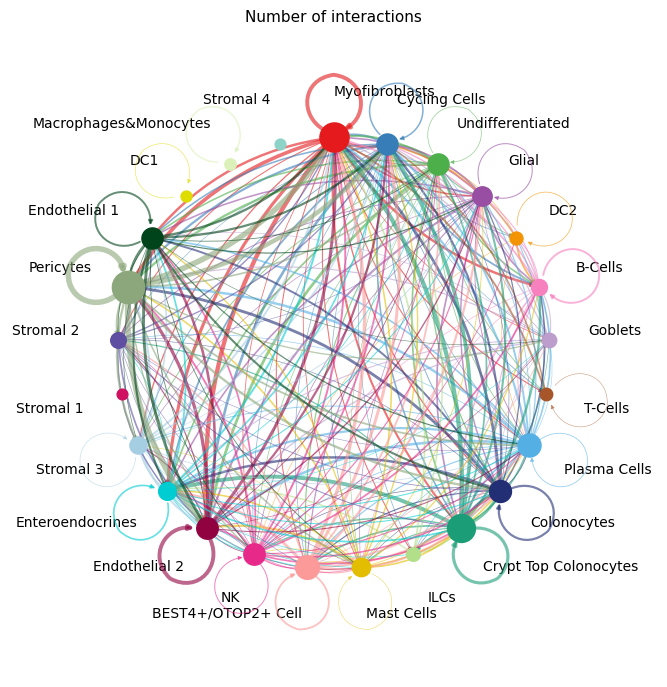

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_multiple_spatial_transcriptomics\01_circle_weight.png


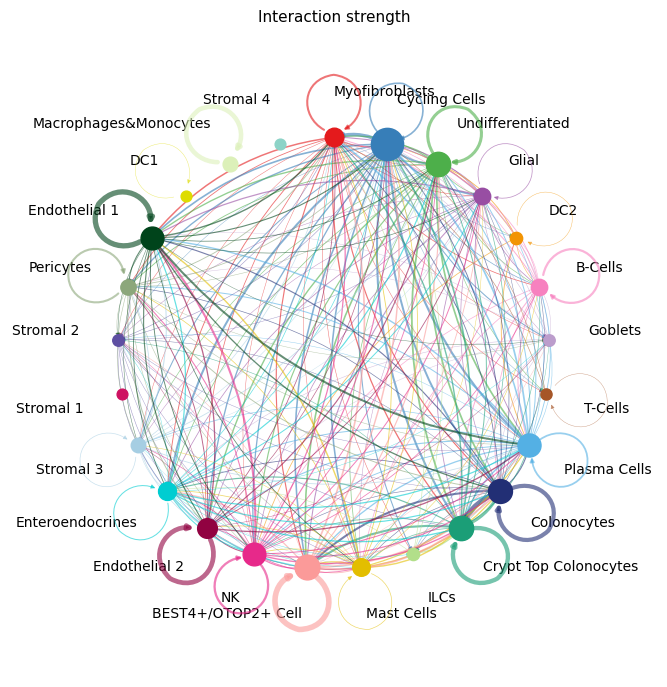

In [10]:
for measure, title, filename in [
    ("count", "Number of interactions", "01_circle_count.png"),
    ("weight", "Interaction strength", "01_circle_weight.png"),
]:
    matrix = np.asarray(cellchat.network[measure])
    fig = cc.plot_network_circle(
        cellchat,
        slot_name="network",
        net_matrix=matrix,
        vertex_weight=matrix.sum(axis=1),
        title_name=title,
        return_fig=True,
    )
    save_fig(fig, filename)

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_multiple_spatial_transcriptomics\02_heatmap_count.png


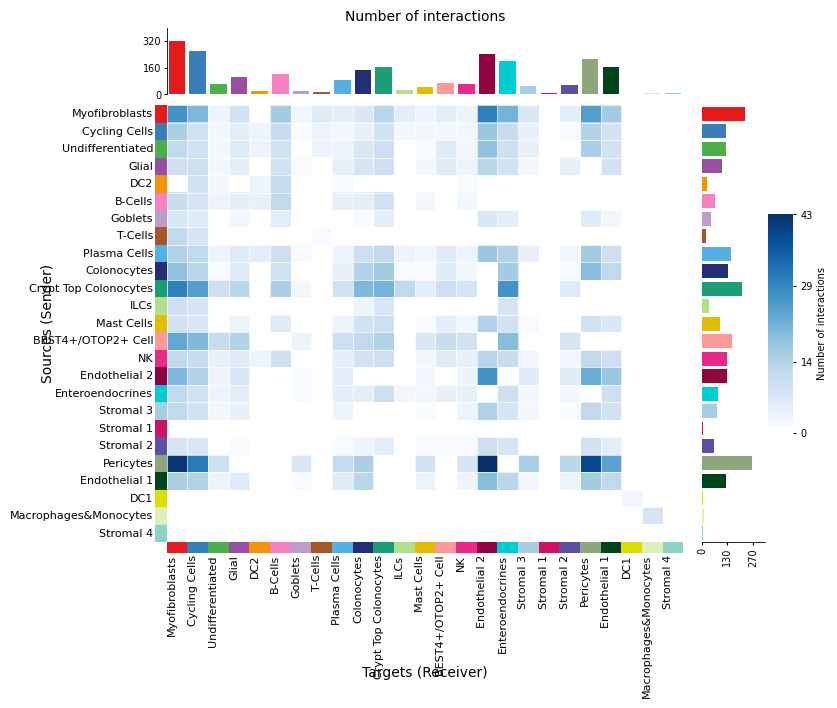

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_multiple_spatial_transcriptomics\02_heatmap_weight.png


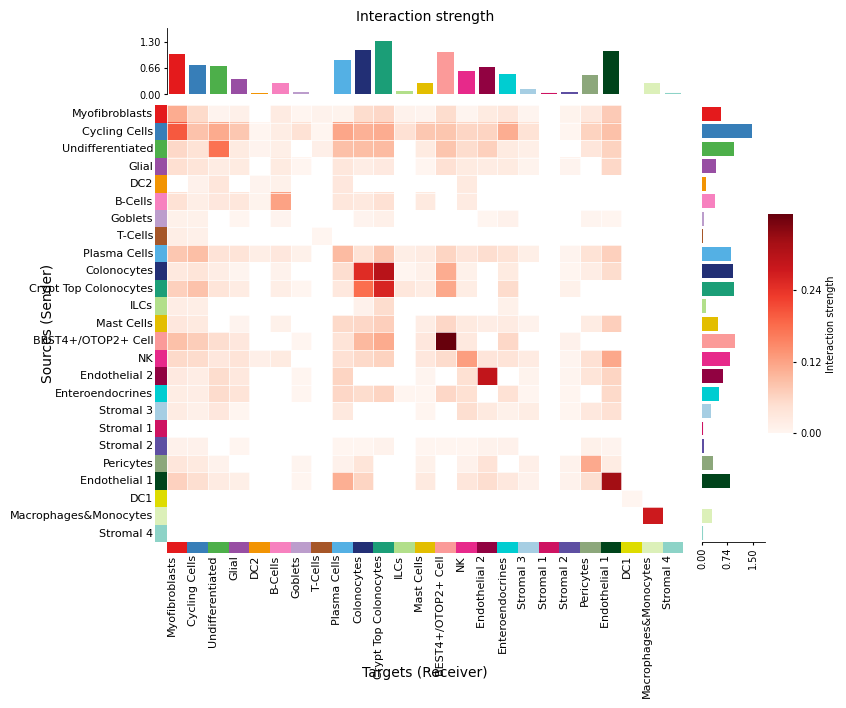

In [11]:
for measure, title, color_heatmap, filename in [
    ("count", "Number of interactions", "Blues", "02_heatmap_count.png"),
    ("weight", "Interaction strength", "Reds", "02_heatmap_weight.png"),
]:
    fig = cc.plot_network_heatmap(
        cellchat,
        slot_name="network",
        measure=measure,
        color_heatmap=color_heatmap,
        title_name=title,
        fig_size=(8, 7),
        return_fig=True,
    )
    save_fig(fig, filename)

### Explore EGF signaling

The R multiple-spatial-dataset vignette uses EGF as a representative secreted signaling pathway. The circle plot summarizes communication between annotated groups. The spatial plot uses all prefixed A1 and A2 spots as a combined coordinate overview; it does not imply physical adjacency between the tissue sections.

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_multiple_spatial_transcriptomics\03_EGF_circle.png


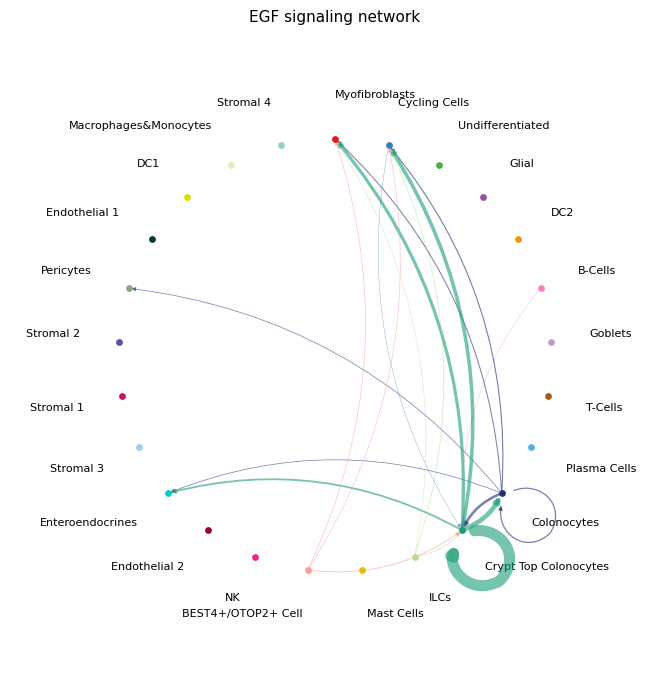

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_multiple_spatial_transcriptomics\03_EGF_spatial_overview.png


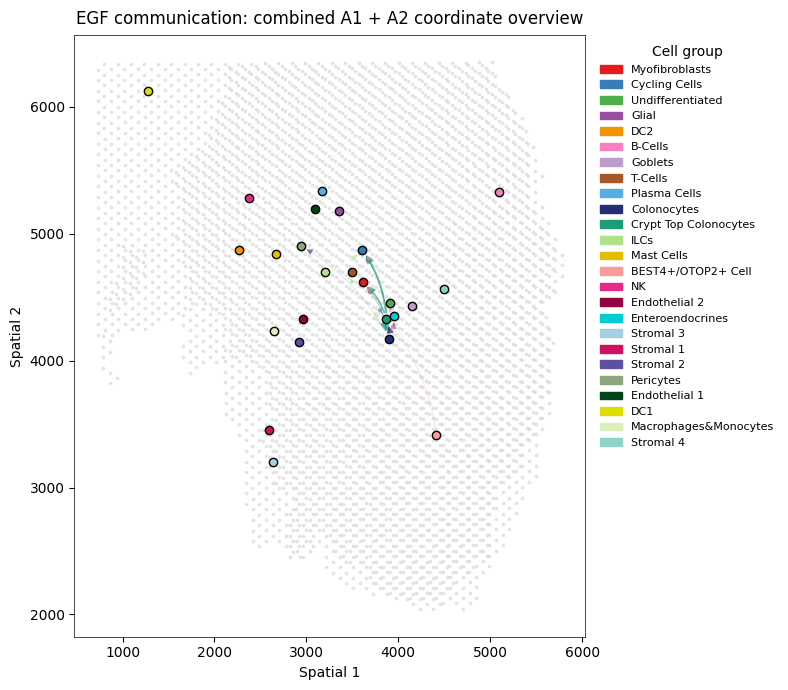

In [12]:
fig = cc.plot_network_aggregate(
    cellchat,
    signaling=pathway_show,
    layout="circle",
    title_name="EGF signaling network",
    fig_size=(8, 7),
    return_fig=True,
)
save_fig(fig, "03_EGF_circle.png")

fig = cc.plot_network_spatial(
    cellchat,
    signaling=pathway_show,
    title_name="EGF communication: combined A1 + A2 coordinate overview",
    vertex_size_max=6,
    edge_width_max=2,
    fig_size=(8, 7),
    return_fig=True,
)
save_fig(fig, "03_EGF_spatial_overview.png")

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_multiple_spatial_transcriptomics\04_EGF_signaling_roles.png


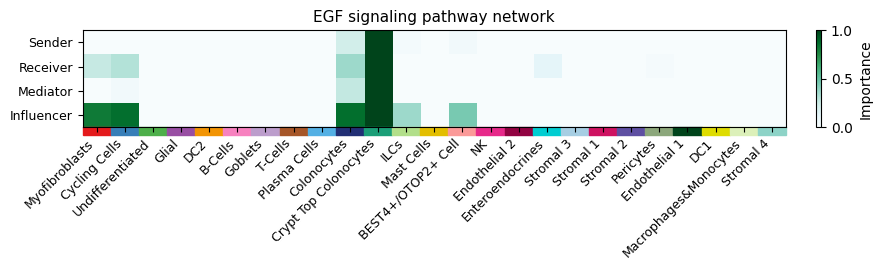

In [13]:
cellchat = cc.compute_network_centrality(cellchat, slot_name="pathway_network")

fig = cc.net_analysis_signaling_role_network(
    cellchat,
    signaling=pathway_show,
    slot_name="pathway_network",
    font_size=9,
    fig_size=(9, 2.8),
    return_fig=True,
)
save_fig(fig, "04_EGF_signaling_roles.png")

,name,contribution
0,AREG - (EGFR+ERBB2),0.471122
1,AREG - EGFR,0.193924
2,HBEGF - (EGFR+ERBB2),0.161046
3,HBEGF - EGFR,0.063458
4,EREG - (EGFR+ERBB2),0.044762
5,TGFA - (EGFR+ERBB2),0.034511
6,EREG - EGFR,0.017604
7,TGFA - EGFR,0.013571


  Saved: E:\Jin\cellchat.python_new\tutorial\figures_multiple_spatial_transcriptomics\05_EGF_contribution.png


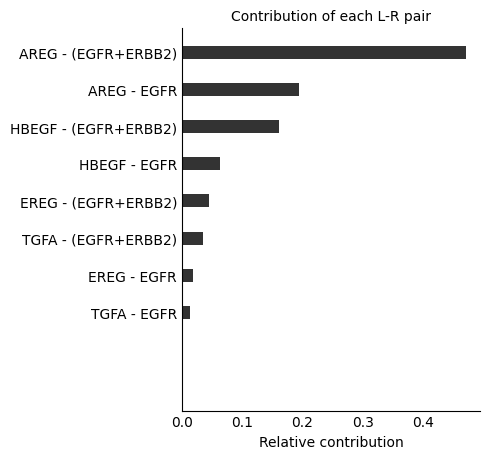

In [14]:
contribution_fig, contribution_table = cc.plot_analysis_contribution(
    cellchat,
    signaling=pathway_show,
    return_data=True,
    return_fig=True,
)
display(contribution_table)
save_fig(contribution_fig, "05_EGF_contribution.png")

### Plot EGF ligand and receptor expression

`plot_spatial_feature` displays expression on the coordinates stored in the merged CellChat object. AREG and EGFR are representative EGF components from the R vignette. As in the preceding network plot, these panels provide a combined A1/A2 coordinate overview; sample prefixes preserve spot identity, while inference remains spatially restricted within each sample.

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_multiple_spatial_transcriptomics\06_spatial_AREG_EGFR.png


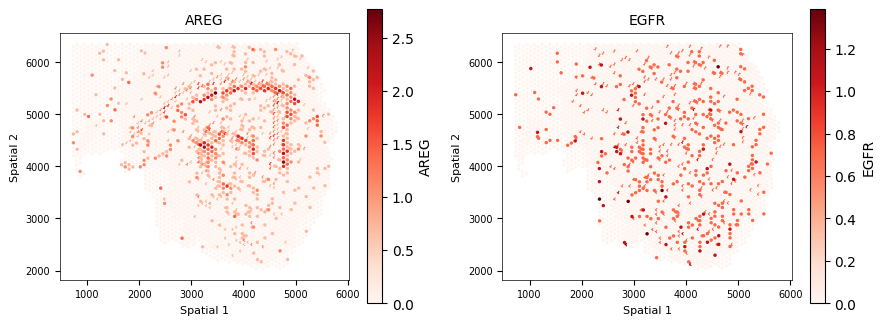

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_multiple_spatial_transcriptomics\06_spatial_EGF_features.png


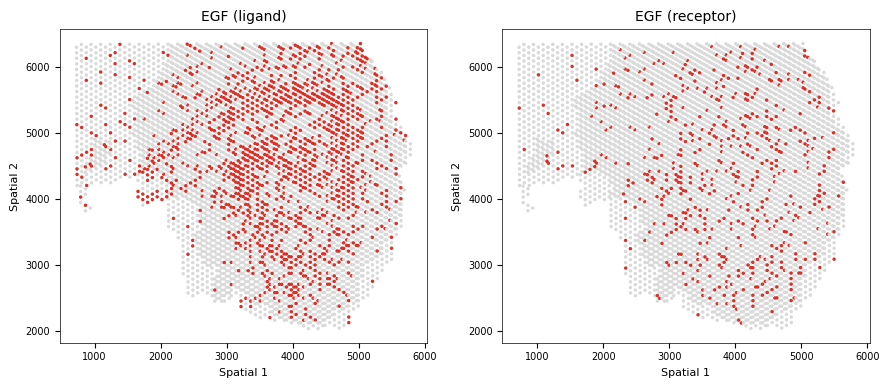

In [15]:
features_show = ["AREG", "EGFR"]
missing_features = [feature for feature in features_show if feature not in cellchat.var_names]
if missing_features:
    raise ValueError(f"Required EGF features are missing: {missing_features}")

fig = cc.plot_spatial_feature(
    cellchat,
    features=features_show,
    slot_data="x",
    color_bar="Reds",
    pt_size=2.5,
    pt_alpha=1.0,
    ncol=2,
    fig_size=(9, 4.5),
    return_fig=True,
)
save_fig(fig, "06_spatial_AREG_EGFR.png")

fig = cc.plot_spatial_feature(
    cellchat,
    signaling=pathway_show,
    color_use=["#d73027", "#d9d9d9"],
    pt_size=2.5,
    pt_alpha=1.0,
    ncol=2,
    fig_size=(9, 4.5),
    return_fig=True,
)
save_fig(fig, "06_spatial_EGF_features.png")

---

## Part IV: Save results

Communication tables are convenient for downstream analysis, while pickle preserves the complete Python CellChat object. Export is opt-in so running the tutorial does not unexpectedly overwrite result files.

In [16]:
export_results = False

summary = pd.Series(
    {
        "samples": len(sample_names),
        "spots": len(metadata),
        "common_genes": len(genes),
        "cell_groups": metadata["cellchat_group"].nunique(),
        "database_interactions": len(db_use["interaction"]),
        "candidate_lr_pairs": len(lr_sig),
        "significant_lr_communications": len(df_net),
        "significant_pathways": len(pathways),
        "analysis_seconds": time.time() - ptm,
    },
    name="value",
)
display(summary.to_frame())

if export_results:
    result_dir.mkdir(parents=True, exist_ok=True)
    lr_path = result_dir / "adult_intestine_A1_A2_LR_communication.csv"
    pathway_path = result_dir / "adult_intestine_A1_A2_pathway_communication.csv"
    summary_path = result_dir / "adult_intestine_A1_A2_summary.csv"
    object_path = result_dir / "adult_intestine_A1_A2_cellchat.pkl"

    df_net.to_csv(lr_path, index=False)
    df_pathway.to_csv(pathway_path, index=False)
    summary.to_csv(summary_path, header=True)
    with object_path.open("wb") as handle:
        pickle.dump(cellchat, handle, protocol=pickle.HIGHEST_PROTOCOL)

    print("L-R table:", lr_path)
    print("Pathway table:", pathway_path)
    print("Summary:", summary_path)
    print("CellChat object:", object_path)
else:
    print("Set export_results=True to write communication tables and the CellChat object.")

,value
samples,2.000000
spots,4965.000000
common_genes,15609.000000
cell_groups,25.000000
database_interactions,1280.000000
candidate_lr_pairs,422.000000
significant_lr_communications,2445.000000
significant_pathways,37.000000
analysis_seconds,319.034952


Set export_results=True to write communication tables and the CellChat object.


## Workflow summary

The complete CellChatPy workflow used in this notebook is:

1. Load and validate each canonical spatial H5 input with `read_spatial_h5`.
2. Retain common genes and prefix spot names with `merge_spatial_inputs`.
3. Create one spatial CellChat object and configure the human secreted-signaling database.
4. Identify candidate interactions and infer distance-aware communication within replicates.
5. Aggregate significant L-R probabilities into pathways, counts, and weights.
6. Inspect EGF signaling and visualize networks, signaling roles, contributions, and spatial expression.
7. Optionally export tidy tables and the complete analysis object.